<a href="https://colab.research.google.com/github/tensorbytes0202/Deep-learning/blob/main/ResNet(imagenet).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile

zip_path = "/content/drive/MyDrive/archive (4).zip"  # apna filename check kar lena
extract_path = "/content/tiny-imagenet"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Done ✅")

Extraction Done ✅


In [5]:
# =====================
# 1. IMPORTS
# =====================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import time
import matplotlib.pyplot as plt


In [6]:
# =====================
# 2. DATA
# =====================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])


In [7]:
train_data = datasets.ImageFolder(
    "/content/tiny-imagenet/tiny-imagenet-200/train",
    transform=transform
)

val_data = datasets.ImageFolder(
    "/content/tiny-imagenet/tiny-imagenet-200/val",   # ✅ FIXED
    transform=transform
)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:

# =====================
# 3. MODEL
# =====================
model = models.resnet18(pretrained=True)

# ✅ FIX: allow training
for param in model.parameters():
    param.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, 200)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 197MB/s]


In [10]:
# =====================
# 4. TRAIN
# =====================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

train_losses = []
val_accuracies = []

start = time.time()

for epoch in range(7):

    # TRAIN
    total_loss = 0
    model.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # VALIDATION
    model.eval()
    correct, total = 0,0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, pred = torch.max(outputs,1)

            total += labels.size(0)
            correct += (pred==labels).sum().item()

    acc = 100 * correct / total
    val_accuracies.append(acc)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Val Acc: {acc:.2f}%")

print("Training Time:", time.time()-start)


Epoch 1, Loss: 1.4241, Val Acc: 0.51%
Epoch 2, Loss: 1.1208, Val Acc: 0.49%
Epoch 3, Loss: 0.9267, Val Acc: 0.52%
Epoch 4, Loss: 0.7793, Val Acc: 0.56%
Epoch 5, Loss: 0.6576, Val Acc: 0.49%
Epoch 6, Loss: 0.5621, Val Acc: 0.61%
Epoch 7, Loss: 0.4778, Val Acc: 0.53%
Training Time: 3844.168316602707


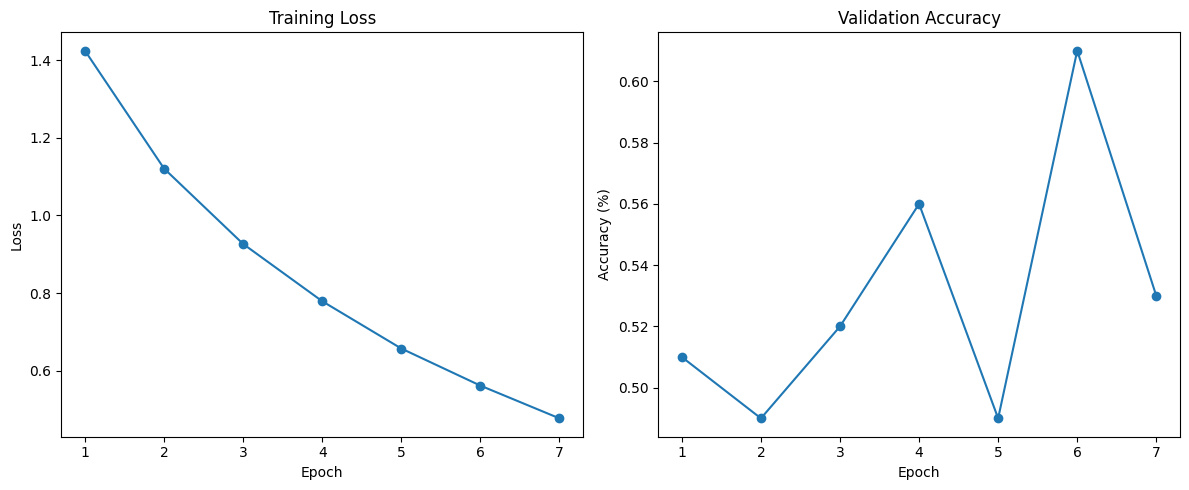

In [11]:
# =====================
# 5. GRAPHS 🔥
# =====================
epochs = range(1, len(train_losses)+1)

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, val_accuracies, marker='o')
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.tight_layout()
plt.show()

In [12]:
import os

# folder create
os.makedirs("outputs/resnet", exist_ok=True)

# save weights
torch.save(model.state_dict(), "outputs/resnet/resnet_model.pth")

print("ResNet model saved ✅")

ResNet model saved ✅
